## 5G-NIDD Preprocessing for Deep Reinforcement Learning (DRL)

This notebook adapts standard network intrusion detection dataset (NIDD) preprocessing techniques for a DRL-based moving-target-defense or intrusion detection environment. It strictly preserves temporal/chronological ordering, defines a standardized 3-class target space (Benign, Scan/Infiltration, DDoS), constructs sequential state observations ($X_t, X_{t+1}$), and rigorously isolates the training set to prevent data leakage. The output consists of neural-network-ready .npy files.

In [1]:
import os
import glob
import json
import pickle
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler
from sklearn.feature_selection import VarianceThreshold
from sklearn.impute import SimpleImputer

# ==========================================
# CONFIGURATION
# ==========================================
# File Paths
DATASET_DIR = "../dataset/5g-nidd/BTS/"
OUTPUT_DIR = "../dataset/5g-nidd/drl_dataset/"

# Split Ratios (Chronological)
TRAIN_RATIO = 0.80
VAL_RATIO = 0.10
TEST_RATIO = 0.10

# Preprocessing Settings
NUMERIC_IMPUTATION_STRATEGY = "median"
CORRELATION_THRESHOLD = 0.90
FEATURE_SELECTION_METHOD = "correlation" # Options: 'correlation', 'mutual_info', 'none'
USE_RESAMPLING = False                   # Default False for DRL to preserve temporal transitions

# DRL Sequence / Temporal Window Settings
USE_SEQUENCES = True
SEQUENCE_LENGTH = 10
STRIDE = 1

# Reproducibility
RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

# Create output directory if it doesn't exist
os.makedirs(OUTPUT_DIR, exist_ok=True)

print("Configuration loaded successfully.")

Configuration loaded successfully.


### Dataset Loading

In [2]:
# # Discover all CSV files in the dataset directory
# csv_files = glob.glob(os.path.join(DATASET_DIR, "*.csv"))

# if not csv_files:
#     print(f"WARNING: No CSV files found in {DATASET_DIR}. Please check your dataset path.")
# else:
#     print(f"Discovered {len(csv_files)} CSV files:")
#     for file in csv_files:
#         print(f" - {os.path.basename(file)}")

# # Load and merge all CSVs
# dataframes = []
# for file in csv_files:
#     print(f"Loading {os.path.basename(file)}...")
#     df_temp = pd.read_csv(file, low_memory=False)
#     dataframes.append(df_temp)

# if dataframes:
#     df_raw = pd.concat(dataframes, ignore_index=True)
#     print(f"\nSuccessfully merged {len(dataframes)} files.")
#     print(f"Total Initial Shape: {df_raw.shape}")

In [3]:
# Path to a single CSV file
CSV_FILE = "../dataset/5g-nidd/5g-nidd.csv"

# Check whether the CSV file exists
if not os.path.isfile(CSV_FILE):
    print(f"WARNING: CSV file not found: {CSV_FILE}")
    df_raw = None
else:
    print(f"Loading {os.path.basename(CSV_FILE)}...")

    # Load the CSV file
    df_raw = pd.read_csv(CSV_FILE, low_memory=False)

    print("CSV file loaded successfully.")
    print(f"Total Initial Shape: {df_raw.shape}")

Loading 5g-nidd.csv...
CSV file loaded successfully.
Total Initial Shape: (1215890, 52)


In [4]:
df_raw.head()

,Unnamed: 0,Seq,Dur,RunTime,Mean,Sum,Min,Max,Proto,sTos,...,sVid,dVid,SrcTCPBase,DstTCPBase,TcpRtt,SynAck,AckDat,Label,Attack Type,Attack Tool
0,0,1,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,icmp,0.0,...,NaN,NaN,NaN,NaN,0.0,0.0,0.0,Benign,Benign,Benign
1,1,2,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,icmp,0.0,...,NaN,NaN,NaN,NaN,0.0,0.0,0.0,Benign,Benign,Benign
2,2,3,4.998020,4.998020,4.998020,4.998020,4.998020,4.998020,udp,0.0,...,NaN,NaN,NaN,NaN,0.0,0.0,0.0,Benign,Benign,Benign
3,3,4,4.998037,4.998037,4.998037,4.998037,4.998037,4.998037,udp,0.0,...,NaN,NaN,NaN,NaN,0.0,0.0,0.0,Benign,Benign,Benign
4,4,5,4.999453,4.999453,4.999453,4.999453,4.999453,4.999453,udp,0.0,...,NaN,NaN,NaN,NaN,0.0,0.0,0.0,Benign,Benign,Benign


In [5]:
df_raw.Label.value_counts()

Malicious    738153
Benign       477737
Name: Label, dtype: int64

In [6]:
df_raw["Attack Type"].value_counts()

Benign            477737
UDPFlood          457340
HTTPFlood         140812
SlowrateDoS        73124
TCPConnectScan     20052
SYNScan            20043
UDPScan            15906
SYNFlood            9721
ICMPFlood           1155
Name: Attack Type, dtype: int64

In [7]:
df_raw.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1215890 entries, 0 to 1215889
Data columns (total 52 columns):
 #   Column       Non-Null Count    Dtype  
---  ------       --------------    -----  
 0   Unnamed: 0   1215890 non-null  int64  
 1   Seq          1215890 non-null  int64  
 2   Dur          1215890 non-null  float64
 3   RunTime      1215890 non-null  float64
 4   Mean         1215890 non-null  float64
 5   Sum          1215890 non-null  float64
 6   Min          1215890 non-null  float64
 7   Max          1215890 non-null  float64
 8   Proto        1215890 non-null  object 
 9   sTos         1215676 non-null  float64
 10  dTos         272823 non-null   float64
 11  sDSb         1215676 non-null  object 
 12  dDSb         272823 non-null   object 
 13  sTtl         1215676 non-null  float64
 14  dTtl         272823 non-null   float64
 15  sHops        1215676 non-null  float64
 16  dHops        272823 non-null   float64
 17  Cause        1215890 non-null  object 
 18  To

#### Initial Dataset Inspection

In [8]:
print("====================================================")
print("DATASET AUDIT & INSPECTION")
print("====================================================\n")

# print(f"Number of files discovered: {len(csv_files) if csv_files else 0}")
print(f"Total records:              {df_raw.shape[0]}")
print(f"Total features:             {df_raw.shape[1]}")

print("\n--- Data Types ---")
print(df_raw.dtypes.value_counts())

print("\n--- Missing Values ---")
missing_counts = df_raw.isnull().sum()
missing_cols = missing_counts[missing_counts > 0]
if not missing_cols.empty:
    print(missing_cols.sort_values(ascending=False))
else:
    print("No missing values detected initially (NaNs may arise after inf replacement).")

print("\n--- Duplicate Rows ---")
dup_count = df_raw.duplicated().sum()
dup_pct = (dup_count / len(df_raw)) * 100
print(f"Duplicates: {dup_count} ({dup_pct:.2f}%)")

# Note: We do not plot everything right away to avoid notebook hangs on massive datasets.
# We will evaluate unique categorical columns dynamically during Feature-Type Processing.

DATASET AUDIT & INSPECTION

Total records:              1215890
Total features:             52

--- Data Types ---
float64    32
int64      12
object      8
dtype: int64

--- Missing Values ---
dVid          1213881
sVid          1101319
DstWin        1038812
DstTCPBase     985843
SrcWin         973470
dTos           943067
dDSb           943067
dTtl           943067
dHops          943067
SrcGap         937219
DstGap         937219
SrcTCPBase     937219
sTos              214
sDSb              214
sTtl              214
sHops             214
dtype: int64

--- Duplicate Rows ---
Duplicates: 1 (0.00%)


#### Label Inspection and Three-Class Mapping

In [9]:
# Identify the label column. Usually 'Label', 'Attack Type', or 'Class' in 5G-NIDD/CIC tools.
# label_col_candidates = ['Label', 'Attack Type', 'label', 'attack_type', 'Attack_Type']
# label_col = next((col for col in label_col_candidates if col in df_raw.columns), None)

# if label_col is None:
#     raise ValueError(f"Could not automatically detect a Label column among: {label_col_candidates}. Please inspect df_raw.columns and set manually.")
label_col = 'Attack Type'
print(f"Detected Label Column: '{label_col}'\n")
print("--- Original Class Distribution ---")
print(df_raw[label_col].value_counts(dropna=False))

Detected Label Column: 'Attack Type'

--- Original Class Distribution ---
Benign            477737
UDPFlood          457340
HTTPFlood         140812
SlowrateDoS        73124
TCPConnectScan     20052
SYNScan            20043
UDPScan            15906
SYNFlood            9721
ICMPFlood           1155
Name: Attack Type, dtype: int64



--- Resulting Mapped Classes ---
   Attack Type            Target  Target_Encoded  Count
        Benign            Benign               0 477737
     HTTPFlood              DDoS               2 140812
     ICMPFlood              DDoS               2   1155
      SYNFlood              DDoS               2   9721
       SYNScan Scan/Infiltration               1  20043
   SlowrateDoS              DDoS               2  73124
TCPConnectScan Scan/Infiltration               1  20052
      UDPFlood              DDoS               2 457340
       UDPScan Scan/Infiltration               1  15906


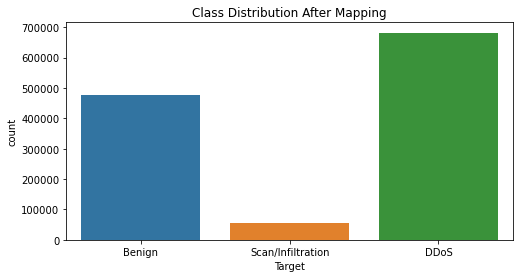

In [10]:
# 
# Define the explicit 3-Class Mapping dict
label_mapping = {
    # Benign
    'Benign': 0,
    'Normal': 0, # Catch-all for other benign naming conventions
    
    # Scan / Infiltration
    'SYNScan': 1,
    'TCPConnectScan': 1, 
    'UDPScan': 1,
    'PortScan': 1, # Just in case
    
    # DDoS
    'ICMPFlood': 2,
    'UDPFlood': 2,
    'SYNFlood': 2,
    'HTTPFlood': 2,
    'SlowrateDoS': 2
}

# Apply Mapping
df_raw['Target_Encoded'] = df_raw[label_col].map(label_mapping)
target_names = {0: 'Benign', 1: 'Scan/Infiltration', 2: 'DDoS'}
df_raw['Target'] = df_raw['Target_Encoded'].map(target_names)

# Check for unmapped labels (dropped because they don't belong to the defined taxonomy)
unmapped = df_raw[df_raw['Target_Encoded'].isnull()]
if not unmapped.empty:
    print(f"\nWARNING: Found {len(unmapped)} records with unmapped labels. They will be dropped.")
    print(unmapped[label_col].value_counts())
    df_raw = df_raw.dropna(subset=['Target_Encoded']).reset_index(drop=True)

df_raw['Target_Encoded'] = df_raw['Target_Encoded'].astype(int)

print("\n--- Resulting Mapped Classes ---")
mapping_summary = df_raw.groupby([label_col, 'Target', 'Target_Encoded']).size().reset_index(name='Count')
print(mapping_summary.to_string(index=False))

# Plot distribution
plt.figure(figsize=(8, 4))
sns.countplot(data=df_raw, x='Target', order=['Benign', 'Scan/Infiltration', 'DDoS'])
plt.title("Class Distribution After Mapping")
plt.show()

#### Data Cleaning

In [11]:
# 6.1 Remove duplicates
print("Removing Duplicate Rows...")
df = df_raw.drop_duplicates().copy()
print(f"Shape after duplicate removal: {df.shape}")

# 6.2 Handle Infinite values (Convert to NaN)
print("Replacing infinite values with NaN...")
numeric_columns = df.select_dtypes(include=[np.number]).columns
inf_count_before = np.isinf(df[numeric_columns]).sum().sum()
df.replace([np.inf, -np.inf], np.nan, inplace=True)
print(f"Total infinity values converted to NaN: {inf_count_before}")

# Missing values check (Imputation logic is defined here, but EXECUTED post-split)
total_missing = df.isnull().sum().sum()
print(f"\nTotal NaNs to be imputed during feature processing: {total_missing}")
print(f"Imputation Strategy: {NUMERIC_IMPUTATION_STRATEGY} (will be fit on training data only)")

Removing Duplicate Rows...
Shape after duplicate removal: (1215889, 54)
Replacing infinite values with NaN...
Total infinity values converted to NaN: 0

Total NaNs to be imputed during feature processing: 11898094
Imputation Strategy: median (will be fit on training data only)


#### Temporal / Session Ordering

In [12]:
# DRL requires temporal correlation between states to learn valid transitions (Markov Decision Process).
# We must order the data chronologically before splitting.

time_col_candidates = ['Timestamp', 'timestamp', 'Flow Start Time', 'flow_start']
time_col = next((col for col in time_col_candidates if col in df.columns), None)

if time_col:
    print(f"Found timestamp column: '{time_col}'. Parsing and sorting...")
    # Convert to datetime (use 'mixed' or specific format if parsing is slow)
    df[time_col] = pd.to_datetime(df[time_col], errors='coerce')
    df = df.sort_values(by=time_col).reset_index(drop=True)
    print("Dataset sorted chronologically.")
else:
    print("WARNING: No obvious timestamp column detected.")
    print("Assuming raw CSV ordering preserves packet/flow chronological order.")

Assuming raw CSV ordering preserves packet/flow chronological order.


#### Train / Validation / Test Split

In [13]:
# CRITICAL: We do NOT use train_test_split with shuffle=True.
# Randomly shuffling destroys the temporal state transitions necessary for DRL agents.

n_samples = len(df)
train_end = int(n_samples * TRAIN_RATIO)
val_end = int(n_samples * (TRAIN_RATIO + VAL_RATIO))

df_train = df.iloc[:train_end].copy()
df_val = df.iloc[train_end:val_end].copy()
df_test = df.iloc[val_end:].copy()

print(f"Chronological Split Results:")
print(f"Training data:   {len(df_train)} samples ({TRAIN_RATIO*100}%)")
print(f"Validation data: {len(df_val)} samples ({VAL_RATIO*100}%)")
print(f"Testing data:    {len(df_test)} samples ({TEST_RATIO*100}%)")

# Extract Labels
y_train = df_train['Target_Encoded'].values
y_val = df_val['Target_Encoded'].values
y_test = df_test['Target_Encoded'].values

Chronological Split Results:
Training data:   972711 samples (80.0%)
Validation data: 121589 samples (10.0%)
Testing data:    121589 samples (10.0%)


#### Feature-Type Processing & Leakage-Free Imputation

In [14]:
# Separate features from identifiers and labels
exclude_cols = [label_col, 'Target', 'Target_Encoded']

# Identify typical network metadata/identifiers that are not continuous numerical features
identifier_cols = ['Flow ID', 'Src IP', 'Dst IP', 'Src Port', 'Dst Port', 'Protocol', 'Timestamp']
for col in identifier_cols:
    if col in df.columns:
        exclude_cols.append(col)

# Keep only valid numeric features for DRL state representation
candidate_features = [col for col in df.columns if col not in exclude_cols]

# Drop object/categorical columns that weren't caught (e.g., weirdly parsed strings)
final_numeric_features = df_train[candidate_features].select_dtypes(include=[np.number]).columns.tolist()

X_train_df = df_train[final_numeric_features]
X_val_df = df_val[final_numeric_features]
X_test_df = df_test[final_numeric_features]

print(f"Selected {len(final_numeric_features)} numeric features for processing.")

# --- FIT IMPUTER ON TRAIN ONLY ---
print("\nFitting imputer on training set only...")
imputer = SimpleImputer(strategy=NUMERIC_IMPUTATION_STRATEGY)
X_train_imputed = imputer.fit_transform(X_train_df)
X_val_imputed = imputer.transform(X_val_df)
X_test_imputed = imputer.transform(X_test_df)

# Convert back to dataframes for column handling in the next step
X_train_df = pd.DataFrame(X_train_imputed, columns=final_numeric_features)
X_val_df = pd.DataFrame(X_val_imputed, columns=final_numeric_features)
X_test_df = pd.DataFrame(X_test_imputed, columns=final_numeric_features)

Selected 44 numeric features for processing.

Fitting imputer on training set only...


#### Feature Selection

In [15]:
# 10.A Remove Zero-Variance Features (Fit on train only)
print("--- Zero-Variance Feature Removal ---")
vt = VarianceThreshold(threshold=0.0)
vt.fit(X_train_df)

non_zero_var_cols = X_train_df.columns[vt.get_support()]
print(f"Removed {len(final_numeric_features) - len(non_zero_var_cols)} constant features.")

X_train_df = X_train_df[non_zero_var_cols]
X_val_df = X_val_df[non_zero_var_cols]
X_test_df = X_test_df[non_zero_var_cols]

# 10.B Remove Highly Correlated Features (Calculate on train only)
if FEATURE_SELECTION_METHOD == "correlation":
    print(f"\n--- Correlation Thresholding (r > {CORRELATION_THRESHOLD}) ---")
    corr_matrix = X_train_df.corr().abs()
    
    # Select upper triangle of correlation matrix
    upper = corr_matrix.where(np.triu(np.ones(corr_matrix.shape), k=1).astype(bool))
    
    # Find features with correlation greater than threshold
    to_drop = [column for column in upper.columns if any(upper[column] > CORRELATION_THRESHOLD)]
    print(f"Removing {len(to_drop)} highly correlated features...")
    
    X_train_df = X_train_df.drop(columns=to_drop)
    X_val_df = X_val_df.drop(columns=to_drop)
    X_test_df = X_test_df.drop(columns=to_drop)
    
elif FEATURE_SELECTION_METHOD == "mutual_info":
    print("Mutual Information feature selection selected (Placeholder for implementation).")
else:
    print("No additional feature selection applied.")

selected_features = X_train_df.columns.tolist()
print(f"\nRemaining Features for DRL State: {len(selected_features)}")

--- Zero-Variance Feature Removal ---
Removed 2 constant features.

--- Correlation Thresholding (r > 0.9) ---
Removing 14 highly correlated features...

Remaining Features for DRL State: 28


#### Feature Scaling

In [16]:
# DRL agents (like PPO/DQN) perform significantly better when state spaces are bounded and normalized.
# MinMaxScaler bounds values to [0, 1], which keeps gradients stable during deep network training.

print("Fitting MinMaxScaler on training data only...")
scaler = MinMaxScaler()

X_train_scaled = scaler.fit_transform(X_train_df).astype(np.float32)
X_val_scaled = scaler.transform(X_val_df).astype(np.float32)
X_test_scaled = scaler.transform(X_test_df).astype(np.float32)

# Save the scaler for live inference in the DRL environment
scaler_path = os.path.join(OUTPUT_DIR, "scaler.pkl")
with open(scaler_path, "wb") as f:
    pickle.dump(scaler, f)
print(f"Scaler saved to {scaler_path}")

Fitting MinMaxScaler on training data only...
Scaler saved to ../dataset/5g-nidd/drl_dataset/scaler.pkl


#### Class Distribution Analysis

--- Training Set Class Distribution ---
Benign (0): 428680 (44.07%)
Scan/Infiltration (1): 56001 (5.76%)
DDoS (2): 488030 (50.17%)


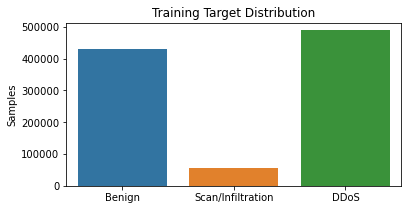

In [17]:
# We analyze the class distribution on the training set to inform our DRL environment design.
train_class_counts = pd.Series(y_train).value_counts().sort_index()

print("--- Training Set Class Distribution ---")
for cls_idx, count in train_class_counts.items():
    print(f"{target_names[cls_idx]} ({cls_idx}): {count} ({count/len(y_train)*100:.2f}%)")
    
# Plot
plt.figure(figsize=(6, 3))
sns.barplot(x=[target_names[i] for i in train_class_counts.index], y=train_class_counts.values)
plt.title("Training Target Distribution")
plt.ylabel("Samples")
plt.show()

#### DRL State Preparation

In [18]:
# The standard flat features are now fully preprocessed and ready for feed-forward (MLP) agents.
X_train = X_train_scaled
X_val = X_val_scaled
X_test = X_test_scaled

y_train = y_train.astype(np.int64)
y_val = y_val.astype(np.int64)
y_test = y_test.astype(np.int64)

print(f"Flat States Ready.")
print(f"X_train: {X_train.shape} | y_train: {y_train.shape}")

Flat States Ready.
X_train: (972711, 28) | y_train: (972711,)


#### Sequence / Temporal Window Construction

In [19]:
def create_sequences(X, y, seq_len, stride=1):
    """
    Creates temporal sequence windows for LSTM/GRU-based DRL agents.
    Does a sliding window across chronological data.
    """
    X_seq, y_seq = [], []
    for i in range(0, len(X) - seq_len + 1, stride):
        X_seq.append(X[i : i + seq_len])
        # The label of the sequence is typically the label of the LAST observation in the window
        y_seq.append(y[i + seq_len - 1])
    return np.array(X_seq, dtype=np.float32), np.array(y_seq, dtype=np.int64)

if USE_SEQUENCES:
    print(f"Constructing Sequence Windows (Length: {SEQUENCE_LENGTH}, Stride: {STRIDE})...")
    # Warning: Standard sliding window operates continuously. If explicit session/base-station 
    # boundaries existed in the dataset and were ordered, we would loop grouped by those IDs. 
    # Here, we assume continuous temporal flow sorting guarantees acceptable proximity.
    
    X_train_seq, y_train_seq = create_sequences(X_train, y_train, SEQUENCE_LENGTH, STRIDE)
    X_val_seq, y_val_seq = create_sequences(X_val, y_val, SEQUENCE_LENGTH, STRIDE)
    X_test_seq, y_test_seq = create_sequences(X_test, y_test, SEQUENCE_LENGTH, STRIDE)
    
    print("Sequence construction complete.")
    print(f"X_train_seq shape: {X_train_seq.shape}")
else:
    print("Sequence construction skipped (USE_SEQUENCES = False).")

Constructing Sequence Windows (Length: 10, Stride: 1)...
Sequence construction complete.
X_train_seq shape: (972702, 10, 28)


#### Dataset Sanity Checks

In [20]:
print("Running automated sanity checks before saving...")

# 1. Shape matching
assert len(X_train) == len(y_train), "Train X and y lengths mismatch!"
assert len(X_val) == len(y_val), "Val X and y lengths mismatch!"
assert len(X_test) == len(y_test), "Test X and y lengths mismatch!"

# 2. Dtype check
assert X_train.dtype == np.float32, f"X_train dtype is {X_train.dtype}, expected float32"
assert y_train.dtype == np.int64, f"y_train dtype is {y_train.dtype}, expected int64"

# 3. NaN/Inf Check
assert np.isnan(X_train).sum() == 0, "NaNs found in X_train!"
assert np.isinf(X_train).sum() == 0, "Infs found in X_train!"
assert np.isnan(X_test).sum() == 0, "NaNs found in X_test!"

# 4. Class Label Limits
valid_classes = {0, 1, 2}
assert set(np.unique(y_train)).issubset(valid_classes), "Unexpected labels found in y_train!"

print("All sanity checks passed successfully! ✅")

Running automated sanity checks before saving...
All sanity checks passed successfully! ✅


#### Save .npy Files

In [21]:
print(f"Saving .npy artifacts to {OUTPUT_DIR}...")

# Save Flat arrays
np.save(os.path.join(OUTPUT_DIR, "X_train.npy"), X_train)
np.save(os.path.join(OUTPUT_DIR, "y_train.npy"), y_train)
np.save(os.path.join(OUTPUT_DIR, "X_val.npy"), X_val)
np.save(os.path.join(OUTPUT_DIR, "y_val.npy"), y_val)
np.save(os.path.join(OUTPUT_DIR, "X_test.npy"), X_test)
np.save(os.path.join(OUTPUT_DIR, "y_test.npy"), y_test)

# Save Sequence arrays if requested
if USE_SEQUENCES:
    np.save(os.path.join(OUTPUT_DIR, "X_train_seq.npy"), X_train_seq)
    np.save(os.path.join(OUTPUT_DIR, "y_train_seq.npy"), y_train_seq)
    np.save(os.path.join(OUTPUT_DIR, "X_val_seq.npy"), X_val_seq)
    np.save(os.path.join(OUTPUT_DIR, "y_val_seq.npy"), y_val_seq)
    np.save(os.path.join(OUTPUT_DIR, "X_test_seq.npy"), X_test_seq)
    np.save(os.path.join(OUTPUT_DIR, "y_test_seq.npy"), y_test_seq)

# Save feature and class names
np.save(os.path.join(OUTPUT_DIR, "feature_names.npy"), np.array(selected_features))
np.save(os.path.join(OUTPUT_DIR, "class_names.npy"), np.array(["Benign", "Scan/Infiltration", "DDoS"]))

print("NumPy files saved successfully.")

Saving .npy artifacts to ../dataset/5g-nidd/drl_dataset/...
NumPy files saved successfully.


#### Save Metadata

In [22]:
metadata = {
    "dataset": "5G-NIDD",
    "preprocessing_logic": "Chronological split, leaked-free scaled, for DRL states",
    "original_samples": int(df_raw.shape[0]),
    "cleaned_samples": int(df.shape[0]),
    "features_before_selection": len(candidate_features),
    "features_after_selection": len(selected_features),
    "train_samples": len(X_train),
    "val_samples": len(X_val),
    "test_samples": len(X_test),
    "scaler": "MinMaxScaler",
    "correlation_threshold": CORRELATION_THRESHOLD,
    "use_resampling": USE_RESAMPLING,
    "sequence_mode": USE_SEQUENCES,
    "sequence_length": SEQUENCE_LENGTH if USE_SEQUENCES else None,
    "stride": STRIDE if USE_SEQUENCES else None,
    "random_seed": RANDOM_STATE,
    "class_mapping": {
        "0": "Benign",
        "1": "Scan/Infiltration",
        "2": "DDoS"
    }
}

with open(os.path.join(OUTPUT_DIR, "preprocessing_metadata.json"), "w") as f:
    json.dump(metadata, f, indent=4)

print("Metadata JSON saved.")

Metadata JSON saved.


### Final Summary

In [23]:
summary_template = f"""
====================================================
5G-NIDD PREPROCESSING SUMMARY FOR DRL
====================================================

Original samples:              {metadata['original_samples']}
Samples after cleaning:        {metadata['cleaned_samples']}
Features before selection:     {metadata['features_before_selection']}
Features after selection:      {metadata['features_after_selection']}

Classes:
0 = Benign
1 = Scan/Infiltration
2 = DDoS

Training samples:              {metadata['train_samples']}
Validation samples:            {metadata['val_samples']}
Testing samples:               {metadata['test_samples']}

Sequence mode:                 {metadata['sequence_mode']}
Sequence length:               {metadata['sequence_length']}

Scaler:                        {metadata['scaler']}
Correlation threshold:         {metadata['correlation_threshold']}

X_train shape:                 {X_train.shape}
X_val shape:                   {X_val.shape}
X_test shape:                  {X_test.shape}
"""

if USE_SEQUENCES:
    summary_template += f"""
X_train_seq shape:             {X_train_seq.shape}
X_val_seq shape:               {X_val_seq.shape}
X_test_seq shape:              {X_test_seq.shape}
"""

summary_template += f"""
Saved files location:          {OUTPUT_DIR}
====================================================
"""

print(summary_template)


5G-NIDD PREPROCESSING SUMMARY FOR DRL

Original samples:              1215890
Samples after cleaning:        1215889
Features before selection:     51
Features after selection:      28

Classes:
0 = Benign
1 = Scan/Infiltration
2 = DDoS

Training samples:              972711
Validation samples:            121589
Testing samples:               121589

Sequence mode:                 True
Sequence length:               10

Scaler:                        MinMaxScaler
Correlation threshold:         0.9

X_train shape:                 (972711, 28)
X_val shape:                   (121589, 28)
X_test shape:                  (121589, 28)

X_train_seq shape:             (972702, 10, 28)
X_val_seq shape:               (121580, 10, 28)
X_test_seq shape:              (121580, 10, 28)

Saved files location:          ../dataset/5g-nidd/drl_dataset/

